# Mol3D Dataset — Graph & Spatial Diameter Histograms

- **Graph diameter**: longest shortest-path distance between any two atoms (in bonds)
- **Spatial diameter**: longest Euclidean distance between any two atoms (in Å)

Shown for the full dataset (3.9M molecules) and for the train/test split used in the experiment (8k / 2k).

In [65]:
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 130

In [66]:
npz = np.load('dataset_per_molecule.npz')
index          = npz['index']             # (3899526,) int32
graph_diam     = npz['graph_diameter']    # (3899526,) int16  — longest shortest path
spatial_diam   = npz['spatial_diameter']  # (3899526,) float32 — max Euclidean dist (Å)
cyclomatic_num = npz['cyclomatic_number'] # (3899526,) int16  — |E| - |V| + 1
num_rings      = npz['num_rings']         # (3899526,) int16  — SSSR ring count

with open('data_split.json') as f:
    split = json.load(f)

train_idx = np.array(split['train'])   # 8000 molecule indices
test_idx  = np.array(split['test'])    # 2000 molecule indices

print(f'Full dataset : {len(index):,} molecules')
print(f'Train split  : {len(train_idx):,} molecules')
print(f'Test split   : {len(test_idx):,} molecules')
print(f'\nGraph diameter  — min={graph_diam.min()}  max={graph_diam.max()}  mean={graph_diam.mean():.1f}')
print(f'Spatial diameter — min={spatial_diam.min():.2f}  max={spatial_diam.max():.2f}  mean={spatial_diam.mean():.2f} Å')
print(f'Cyclomatic num   — min={cyclomatic_num.min()}  max={cyclomatic_num.max()}  mean={cyclomatic_num.mean():.2f}')
print(f'Num rings        — min={num_rings.min()}  max={num_rings.max()}  mean={num_rings.mean():.2f}')

Full dataset : 3,899,526 molecules
Train split  : 8,000 molecules
Test split   : 2,000 molecules

Graph diameter  — min=0  max=41  mean=9.7
Spatial diameter — min=0.00  max=75.49  mean=9.55 Å
Cyclomatic num   — min=-4  max=10  mean=1.41
Num rings        — min=0  max=15  mean=1.42


## Full Dataset

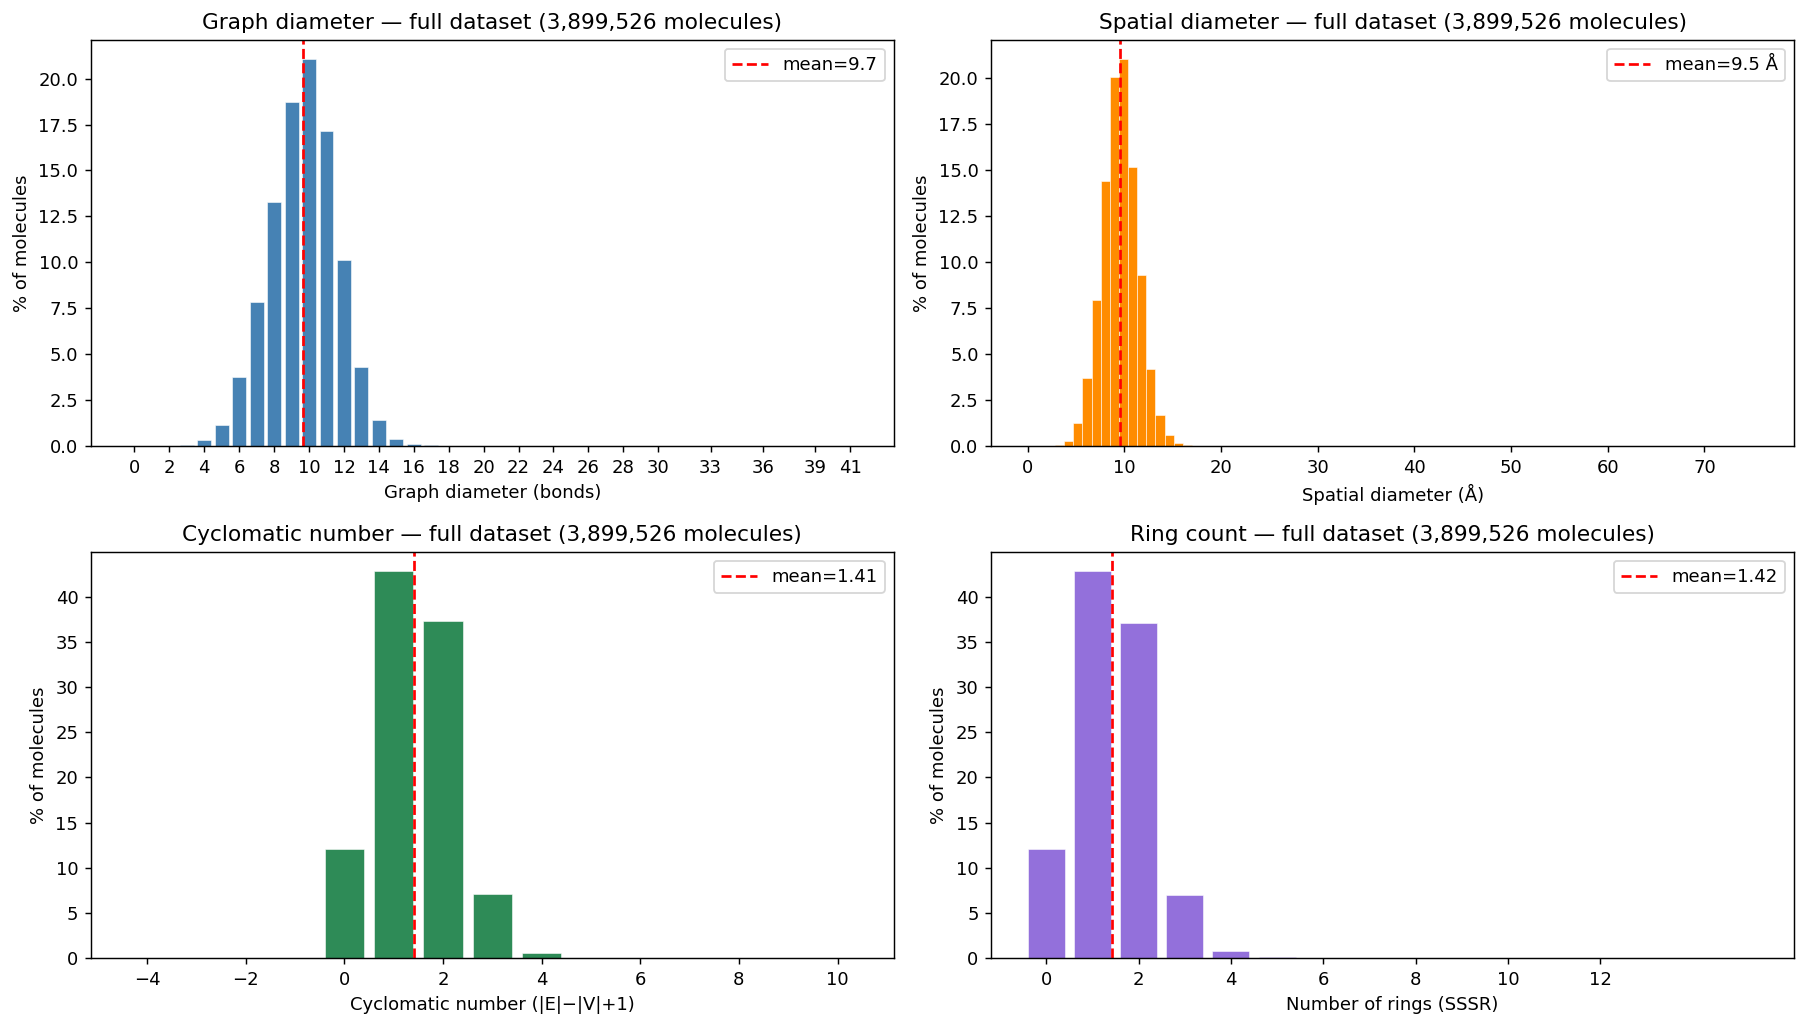

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Graph diameter — discrete, use bar
ax = axes[0, 0]
values, counts = np.unique(graph_diam, return_counts=True)
ax.bar(values, counts / len(graph_diam) * 100, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Graph diameter (bonds)')
ax.set_ylabel('% of molecules')
ax.set_title(f'Graph diameter — full dataset ({len(graph_diam):,} molecules)')
ax.set_xticks(values[::2])
ax.axvline(graph_diam.mean(), color='red', linestyle='--', linewidth=1.5, label=f'mean={graph_diam.mean():.1f}')
ax.legend()

# Spatial diameter — continuous, use histogram
ax = axes[0, 1]
ax.hist(spatial_diam, bins=80, color='darkorange', edgecolor='white', linewidth=0.3,
        weights=np.ones(len(spatial_diam)) / len(spatial_diam) * 100)
ax.set_xlabel('Spatial diameter (Å)')
ax.set_ylabel('% of molecules')
ax.set_title(f'Spatial diameter — full dataset ({len(spatial_diam):,} molecules)')
ax.axvline(spatial_diam.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'mean={spatial_diam.mean():.1f} Å')
ax.legend()

# Cyclomatic number — discrete, use bar
ax = axes[1, 0]
values, counts = np.unique(cyclomatic_num, return_counts=True)
ax.bar(values, counts / len(cyclomatic_num) * 100, color='seagreen', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Cyclomatic number (|E|−|V|+1)')
ax.set_ylabel('% of molecules')
ax.set_title(f'Cyclomatic number — full dataset ({len(cyclomatic_num):,} molecules)')
ax.set_xticks(values[::2] if len(values) > 10 else values)
ax.axvline(cyclomatic_num.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'mean={cyclomatic_num.mean():.2f}')
ax.legend()

# Number of rings — discrete, use bar
ax = axes[1, 1]
values, counts = np.unique(num_rings, return_counts=True)
ax.bar(values, counts / len(num_rings) * 100, color='mediumpurple', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Number of rings (SSSR)')
ax.set_ylabel('% of molecules')
ax.set_title(f'Ring count — full dataset ({len(num_rings):,} molecules)')
ax.set_xticks(values[::2] if len(values) > 10 else values)
ax.axvline(num_rings.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'mean={num_rings.mean():.2f}')
ax.legend()

plt.tight_layout()
plt.show()

## Train / Test Split

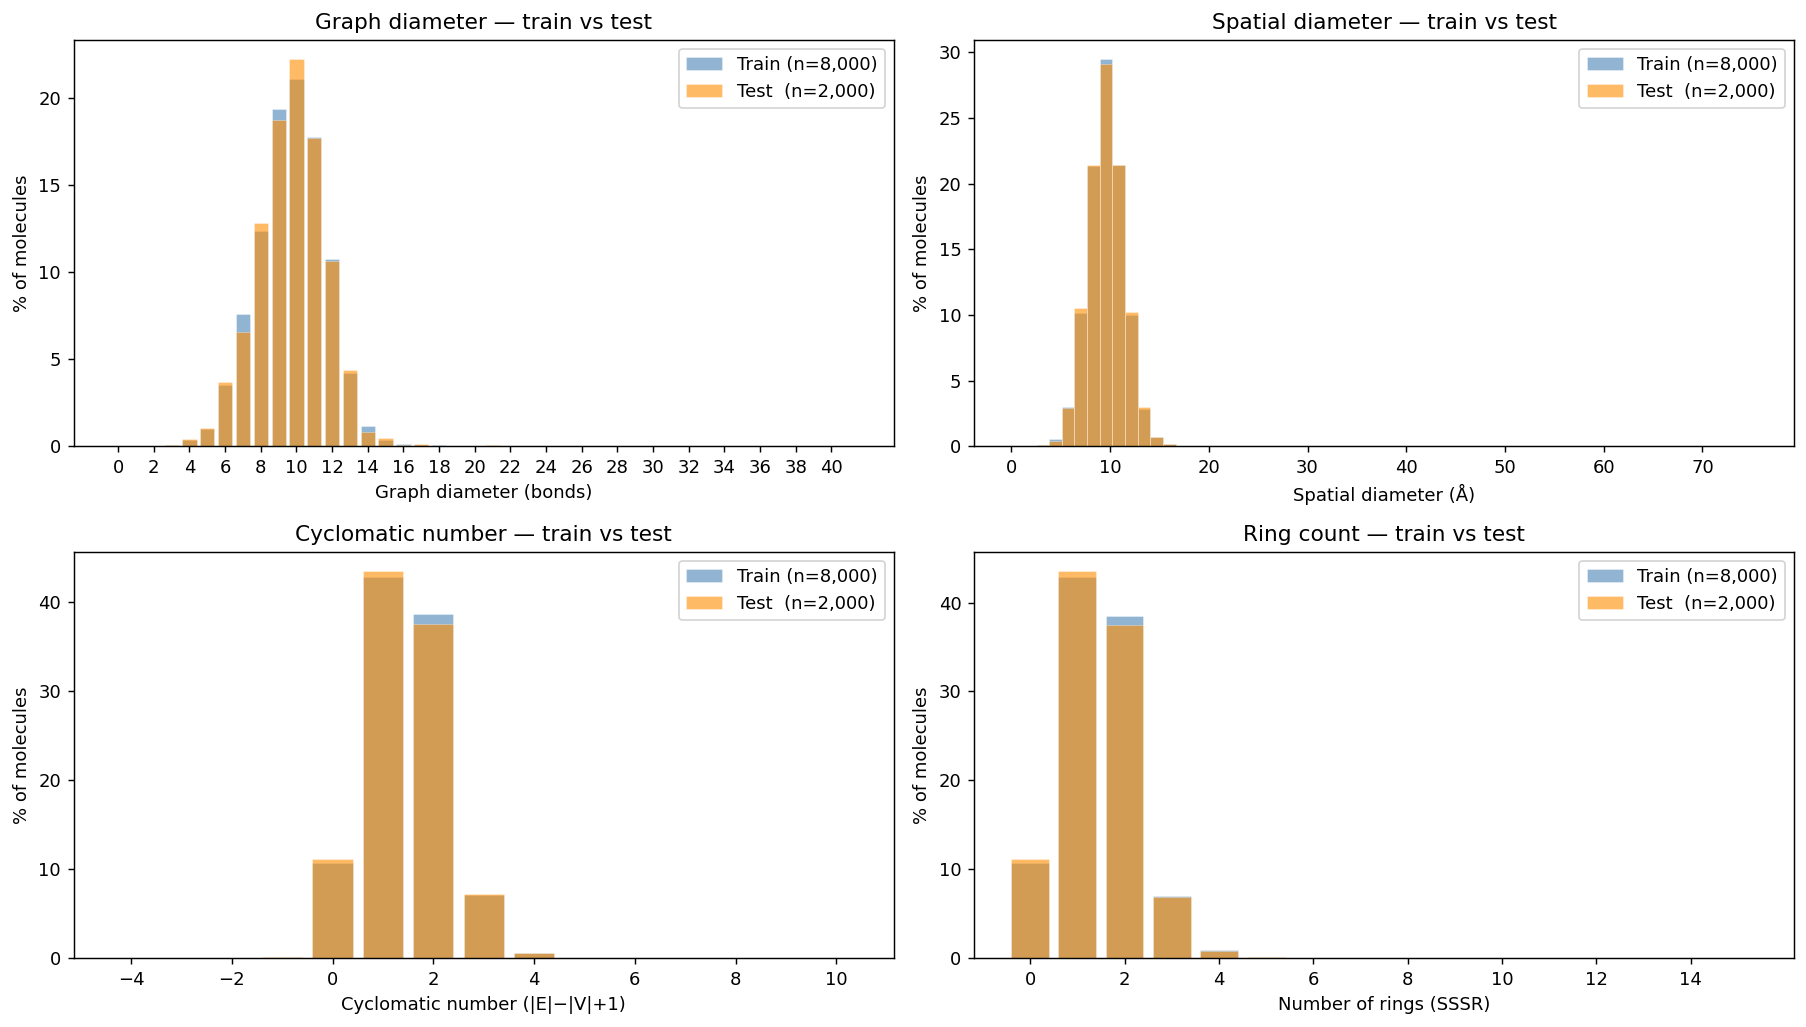

In [68]:
gd_train = graph_diam[train_idx]
gd_test  = graph_diam[test_idx]
sd_train = spatial_diam[train_idx]
sd_test  = spatial_diam[test_idx]
cn_train = cyclomatic_num[train_idx]
cn_test  = cyclomatic_num[test_idx]
nr_train = num_rings[train_idx]
nr_test  = num_rings[test_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Graph diameter — train vs test
ax = axes[0, 0]
all_vals = np.arange(graph_diam.min(), graph_diam.max() + 1)
for arr, label, color in [(gd_train, f'Train (n={len(gd_train):,})', 'steelblue'),
                           (gd_test,  f'Test  (n={len(gd_test):,})',  'darkorange')]:
    counts = np.array([(arr == v).sum() for v in all_vals])
    ax.bar(all_vals, counts / len(arr) * 100, alpha=0.6, label=label, color=color,
           edgecolor='white', linewidth=0.3)
ax.set_xlabel('Graph diameter (bonds)')
ax.set_ylabel('% of molecules')
ax.set_title('Graph diameter — train vs test')
ax.set_xticks(all_vals[::2])
ax.legend()

# Spatial diameter — train vs test
ax = axes[0, 1]
bins = np.linspace(spatial_diam.min(), spatial_diam.max(), 60)
for arr, label, color in [(sd_train, f'Train (n={len(sd_train):,})', 'steelblue'),
                           (sd_test,  f'Test  (n={len(sd_test):,})',  'darkorange')]:
    ax.hist(arr, bins=bins, alpha=0.6, label=label, color=color,
            weights=np.ones(len(arr)) / len(arr) * 100, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Spatial diameter (Å)')
ax.set_ylabel('% of molecules')
ax.set_title('Spatial diameter — train vs test')
ax.legend()

# Cyclomatic number — train vs test
ax = axes[1, 0]
all_vals_cn = np.arange(cyclomatic_num.min(), cyclomatic_num.max() + 1)
for arr, label, color in [(cn_train, f'Train (n={len(cn_train):,})', 'steelblue'),
                           (cn_test,  f'Test  (n={len(cn_test):,})',  'darkorange')]:
    counts = np.array([(arr == v).sum() for v in all_vals_cn])
    ax.bar(all_vals_cn, counts / len(arr) * 100, alpha=0.6, label=label, color=color,
           edgecolor='white', linewidth=0.3)
ax.set_xlabel('Cyclomatic number (|E|−|V|+1)')
ax.set_ylabel('% of molecules')
ax.set_title('Cyclomatic number — train vs test')
ax.set_xticks(all_vals_cn[::2] if len(all_vals_cn) > 10 else all_vals_cn)
ax.legend()

# Number of rings — train vs test
ax = axes[1, 1]
all_vals_nr = np.arange(num_rings.min(), num_rings.max() + 1)
for arr, label, color in [(nr_train, f'Train (n={len(nr_train):,})', 'steelblue'),
                           (nr_test,  f'Test  (n={len(nr_test):,})',  'darkorange')]:
    counts = np.array([(arr == v).sum() for v in all_vals_nr])
    ax.bar(all_vals_nr, counts / len(arr) * 100, alpha=0.6, label=label, color=color,
           edgecolor='white', linewidth=0.3)
ax.set_xlabel('Number of rings (SSSR)')
ax.set_ylabel('% of molecules')
ax.set_title('Ring count — train vs test')
ax.set_xticks(all_vals_nr[::2] if len(all_vals_nr) > 10 else all_vals_nr)
ax.legend()

plt.tight_layout()
plt.show()

## Split vs Full Dataset

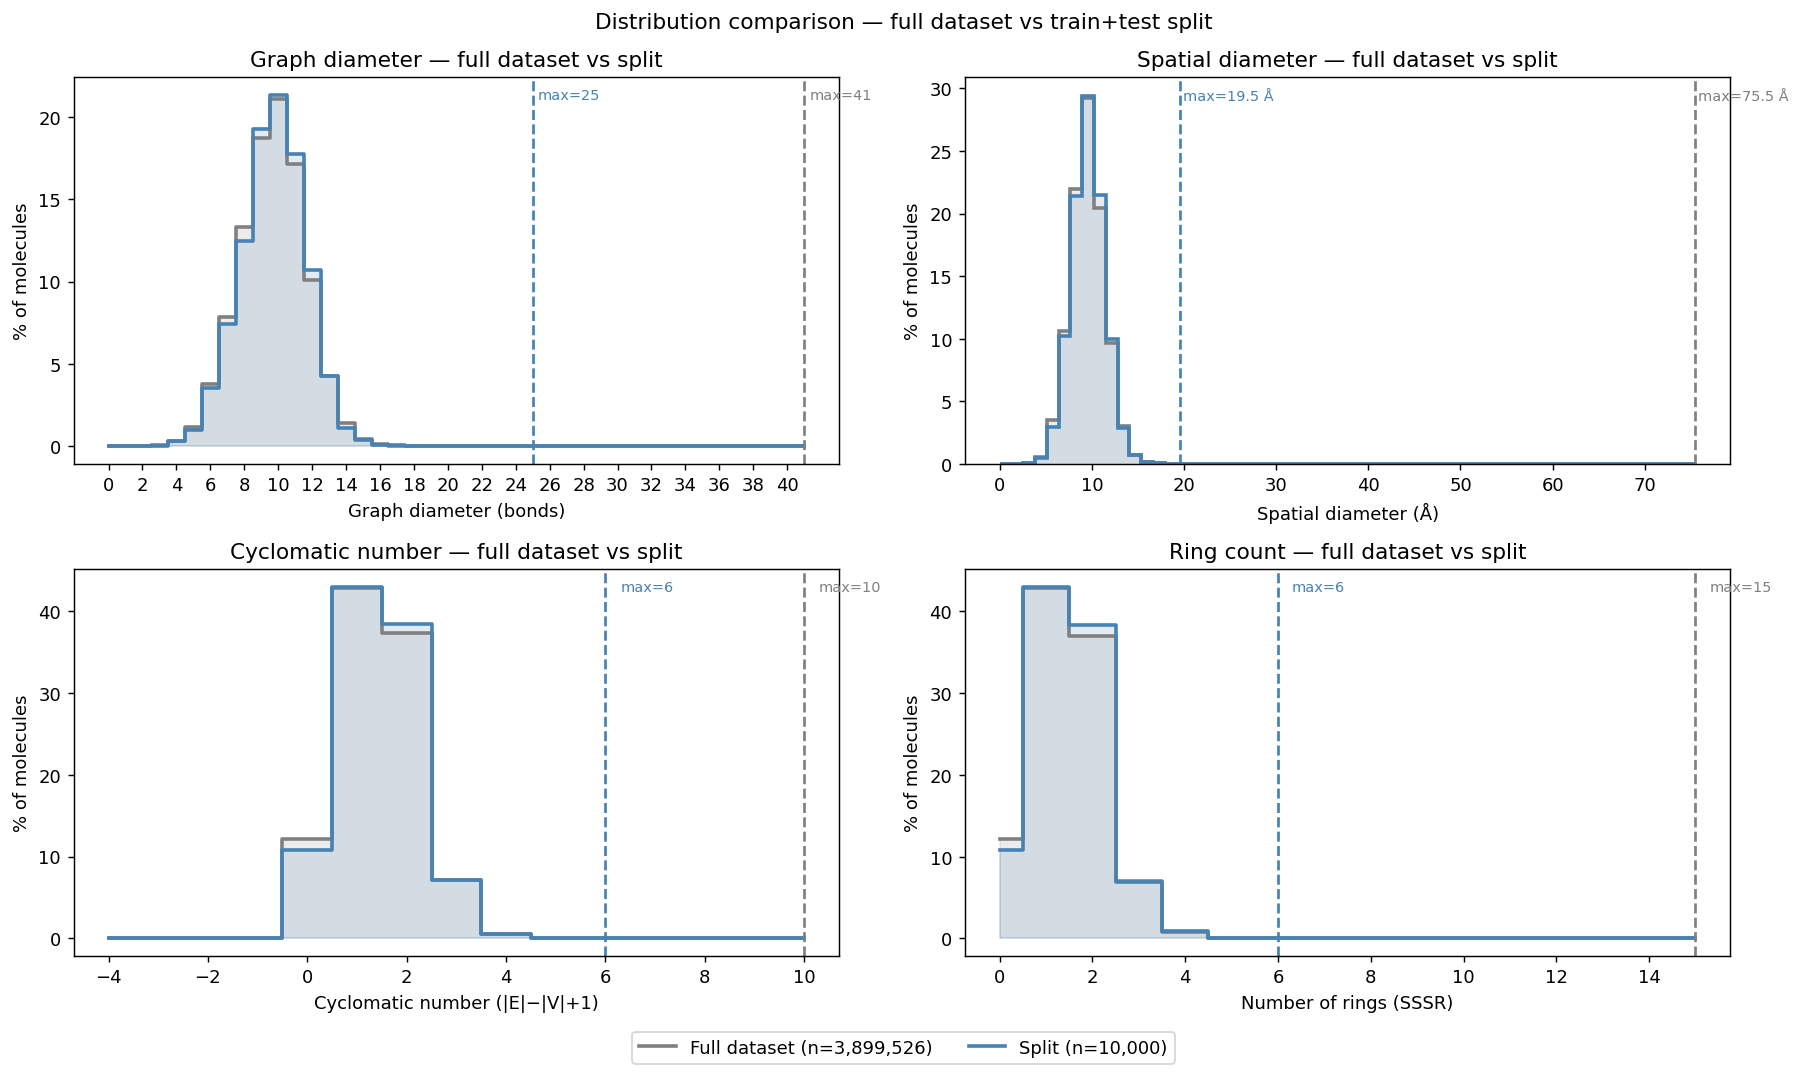

In [69]:
split_idx = np.concatenate([train_idx, test_idx])
gd_split  = graph_diam[split_idx]
sd_split  = spatial_diam[split_idx]
cn_split  = cyclomatic_num[split_idx]
nr_split  = num_rings[split_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Graph diameter
ax = axes[0, 0]
all_vals = np.arange(graph_diam.min(), graph_diam.max() + 1)
pairs = [
    (graph_diam, f'Full dataset (n={len(graph_diam):,})', 'gray'),
    (gd_split,   f'Split (n={len(gd_split):,})',          'steelblue'),
]
handles = []
for arr, label, color in pairs:
    counts = np.array([(arr == v).sum() for v in all_vals], dtype=float)
    h, = ax.step(all_vals, counts / len(arr) * 100, where='mid',
                 label=label, color=color, linewidth=2)
    ax.fill_between(all_vals, counts / len(arr) * 100, step='mid', alpha=0.15, color=color)
    handles.append(h)
ymax = ax.get_ylim()[1]
for arr, _, color in pairs:
    max_val = int(arr.max())
    ax.axvline(max_val, color=color, linestyle='--', linewidth=1.5)
    ax.text(max_val + 0.3, ymax * 0.97, f'max={max_val}',
            color=color, fontsize=8, va='top')
ax.set_xlabel('Graph diameter (bonds)')
ax.set_ylabel('% of molecules')
ax.set_title('Graph diameter — full dataset vs split')
ax.set_xticks(all_vals[::2])

# Spatial diameter
ax = axes[0, 1]
bins = np.linspace(spatial_diam.min(), spatial_diam.max(), 60)
pairs_sd = [
    (spatial_diam, f'Full dataset (n={len(spatial_diam):,})', 'gray'),
    (sd_split,     f'Split (n={len(sd_split):,})',             'steelblue'),
]
for arr, label, color in pairs_sd:
    ax.hist(arr, bins=bins, histtype='step', linewidth=2,
            weights=np.ones(len(arr)) / len(arr) * 100,
            label=label, color=color)
    ax.hist(arr, bins=bins, histtype='stepfilled', alpha=0.15,
            weights=np.ones(len(arr)) / len(arr) * 100, color=color)
ymax = ax.get_ylim()[1]
for arr, _, color in pairs_sd:
    max_val = float(arr.max())
    ax.axvline(max_val, color=color, linestyle='--', linewidth=1.5)
    ax.text(max_val + 0.3, ymax * 0.97, f'max={max_val:.1f} Å',
            color=color, fontsize=8, va='top')
ax.set_xlabel('Spatial diameter (Å)')
ax.set_ylabel('% of molecules')
ax.set_title('Spatial diameter — full dataset vs split')

# Cyclomatic number
ax = axes[1, 0]
all_vals_cn = np.arange(cyclomatic_num.min(), cyclomatic_num.max() + 1)
pairs_cn = [
    (cyclomatic_num, f'Full dataset (n={len(cyclomatic_num):,})', 'gray'),
    (cn_split,       f'Split (n={len(cn_split):,})',               'steelblue'),
]
for arr, label, color in pairs_cn:
    counts = np.array([(arr == v).sum() for v in all_vals_cn], dtype=float)
    ax.step(all_vals_cn, counts / len(arr) * 100, where='mid',
            label=label, color=color, linewidth=2)
    ax.fill_between(all_vals_cn, counts / len(arr) * 100, step='mid', alpha=0.15, color=color)
ymax = ax.get_ylim()[1]
for arr, _, color in pairs_cn:
    max_val = int(arr.max())
    ax.axvline(max_val, color=color, linestyle='--', linewidth=1.5)
    ax.text(max_val + 0.3, ymax * 0.97, f'max={max_val}',
            color=color, fontsize=8, va='top')
ax.set_xlabel('Cyclomatic number (|E|−|V|+1)')
ax.set_ylabel('% of molecules')
ax.set_title('Cyclomatic number — full dataset vs split')
ax.set_xticks(all_vals_cn[::2] if len(all_vals_cn) > 10 else all_vals_cn)

# Number of rings
ax = axes[1, 1]
all_vals_nr = np.arange(num_rings.min(), num_rings.max() + 1)
pairs_nr = [
    (num_rings, f'Full dataset (n={len(num_rings):,})', 'gray'),
    (nr_split,  f'Split (n={len(nr_split):,})',          'steelblue'),
]
for arr, label, color in pairs_nr:
    counts = np.array([(arr == v).sum() for v in all_vals_nr], dtype=float)
    ax.step(all_vals_nr, counts / len(arr) * 100, where='mid',
            label=label, color=color, linewidth=2)
    ax.fill_between(all_vals_nr, counts / len(arr) * 100, step='mid', alpha=0.15, color=color)
ymax = ax.get_ylim()[1]
for arr, _, color in pairs_nr:
    max_val = int(arr.max())
    ax.axvline(max_val, color=color, linestyle='--', linewidth=1.5)
    ax.text(max_val + 0.3, ymax * 0.97, f'max={max_val}',
            color=color, fontsize=8, va='top')
ax.set_xlabel('Number of rings (SSSR)')
ax.set_ylabel('% of molecules')
ax.set_title('Ring count — full dataset vs split')
ax.set_xticks(all_vals_nr[::2] if len(all_vals_nr) > 10 else all_vals_nr)

fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.04), frameon=True)
plt.suptitle('Distribution comparison — full dataset vs train+test split', fontsize=12)
plt.tight_layout()
plt.show()

## Summary Statistics

In [70]:
import pandas as pd

rows = []
for name, gd, sd, cn, nr in [
        ('Full dataset', graph_diam, spatial_diam, cyclomatic_num, num_rings),
        ('Train',        gd_train,   sd_train,     cn_train,       nr_train),
        ('Test',         gd_test,    sd_test,      cn_test,        nr_test)]:
    rows.append({
        'split':             name,
        'n':                 len(gd),
        'graph_diam_mean':   round(float(gd.mean()), 2),
        'graph_diam_std':    round(float(gd.std()),  2),
        'graph_diam_max':    int(gd.max()),
        'spatial_diam_mean': round(float(sd.mean()), 2),
        'spatial_diam_std':  round(float(sd.std()),  2),
        'spatial_diam_max':  round(float(sd.max()),  2),
        'cyclomatic_mean':   round(float(cn.mean()), 2),
        'cyclomatic_std':    round(float(cn.std()),  2),
        'cyclomatic_max':    int(cn.max()),
        'num_rings_mean':    round(float(nr.mean()), 2),
        'num_rings_std':     round(float(nr.std()),  2),
        'num_rings_max':     int(nr.max()),
    })

pd.DataFrame(rows).set_index('split')

,n,graph_diam_mean,graph_diam_std,graph_diam_max,spatial_diam_mean,spatial_diam_std,spatial_diam_max,cyclomatic_mean,cyclomatic_std,cyclomatic_max,num_rings_mean,num_rings_std,num_rings_max
split,,,,,,,,,,,,,
Full dataset,3899526,9.67,1.96,41,9.55,1.84,75.49,1.41,0.82,10,1.42,0.83,15
Train,8000,9.72,1.93,25,9.60,1.81,19.54,1.44,0.81,6,1.45,0.82,6
Test,2000,9.73,1.91,21,9.61,1.80,16.03,1.42,0.81,4,1.43,0.82,5


## Model Error vs Structural Complexity\n\nFor each model: mean absolute error (averaged across 3 runs) per molecule, plotted against graph diameter and spatial diameter. The dashed line is a linear regression indicating the trend.

In [71]:
import json
from pathlib import Path

FILES = {
    'CT-coords': 'results/results_mol3d_ct_coords.json',
    'CT-simple': 'results/results_mol3d_ct_simple.json',
    'CT-full':   'results/results_mol3d_ct_full.json',
    'GCN':       'results/results_mol3d_gcn.json',
    'GAT':       'results/results_mol3d_gat.json',
    'GIN':       'results/results_mol3d_gin.json',
    'SchNet':    'results/results_mol3d_schnet.json',
}

COLORS = {
    'CT-coords': '#4C72B0',
    'CT-simple': '#64B5CD',
    'CT-full':   '#1A5276',
    'GCN':       '#DD8452',
    'GAT':       '#55A868',
    'GIN':       '#C44E52',
    'SchNet':    '#8172B2',
}

model_errors = {}
for label, fname in FILES.items():
    if not Path(fname).exists():
        print(f'Missing: {fname}')
        continue
    with open(fname) as f:
        d = json.load(f)

    err_by_idx = {}
    for run in d['runs']:
        for p in run['predictions']:
            idx = p['index']
            err = abs(p['pred'] - p['true'])
            if idx not in err_by_idx:
                err_by_idx[idx] = []
            err_by_idx[idx].append(err)

    indices   = np.array(list(err_by_idx.keys()))
    mean_errs = np.array([np.mean(err_by_idx[i]) for i in indices])
    model_errors[label] = {
        'gd':  graph_diam[indices].astype(float),
        'sd':  spatial_diam[indices].astype(float),
        'cn':  cyclomatic_num[indices].astype(float),
        'nr':  num_rings[indices].astype(float),
        'err': mean_errs,
    }

print('Models loaded:', list(model_errors.keys()))
print(f'Test molecules per model: {len(next(iter(model_errors.values()))["err"])}')

Models loaded: ['CT-coords', 'CT-simple', 'CT-full', 'GCN', 'GAT', 'GIN', 'SchNet']
Test molecules per model: 2000


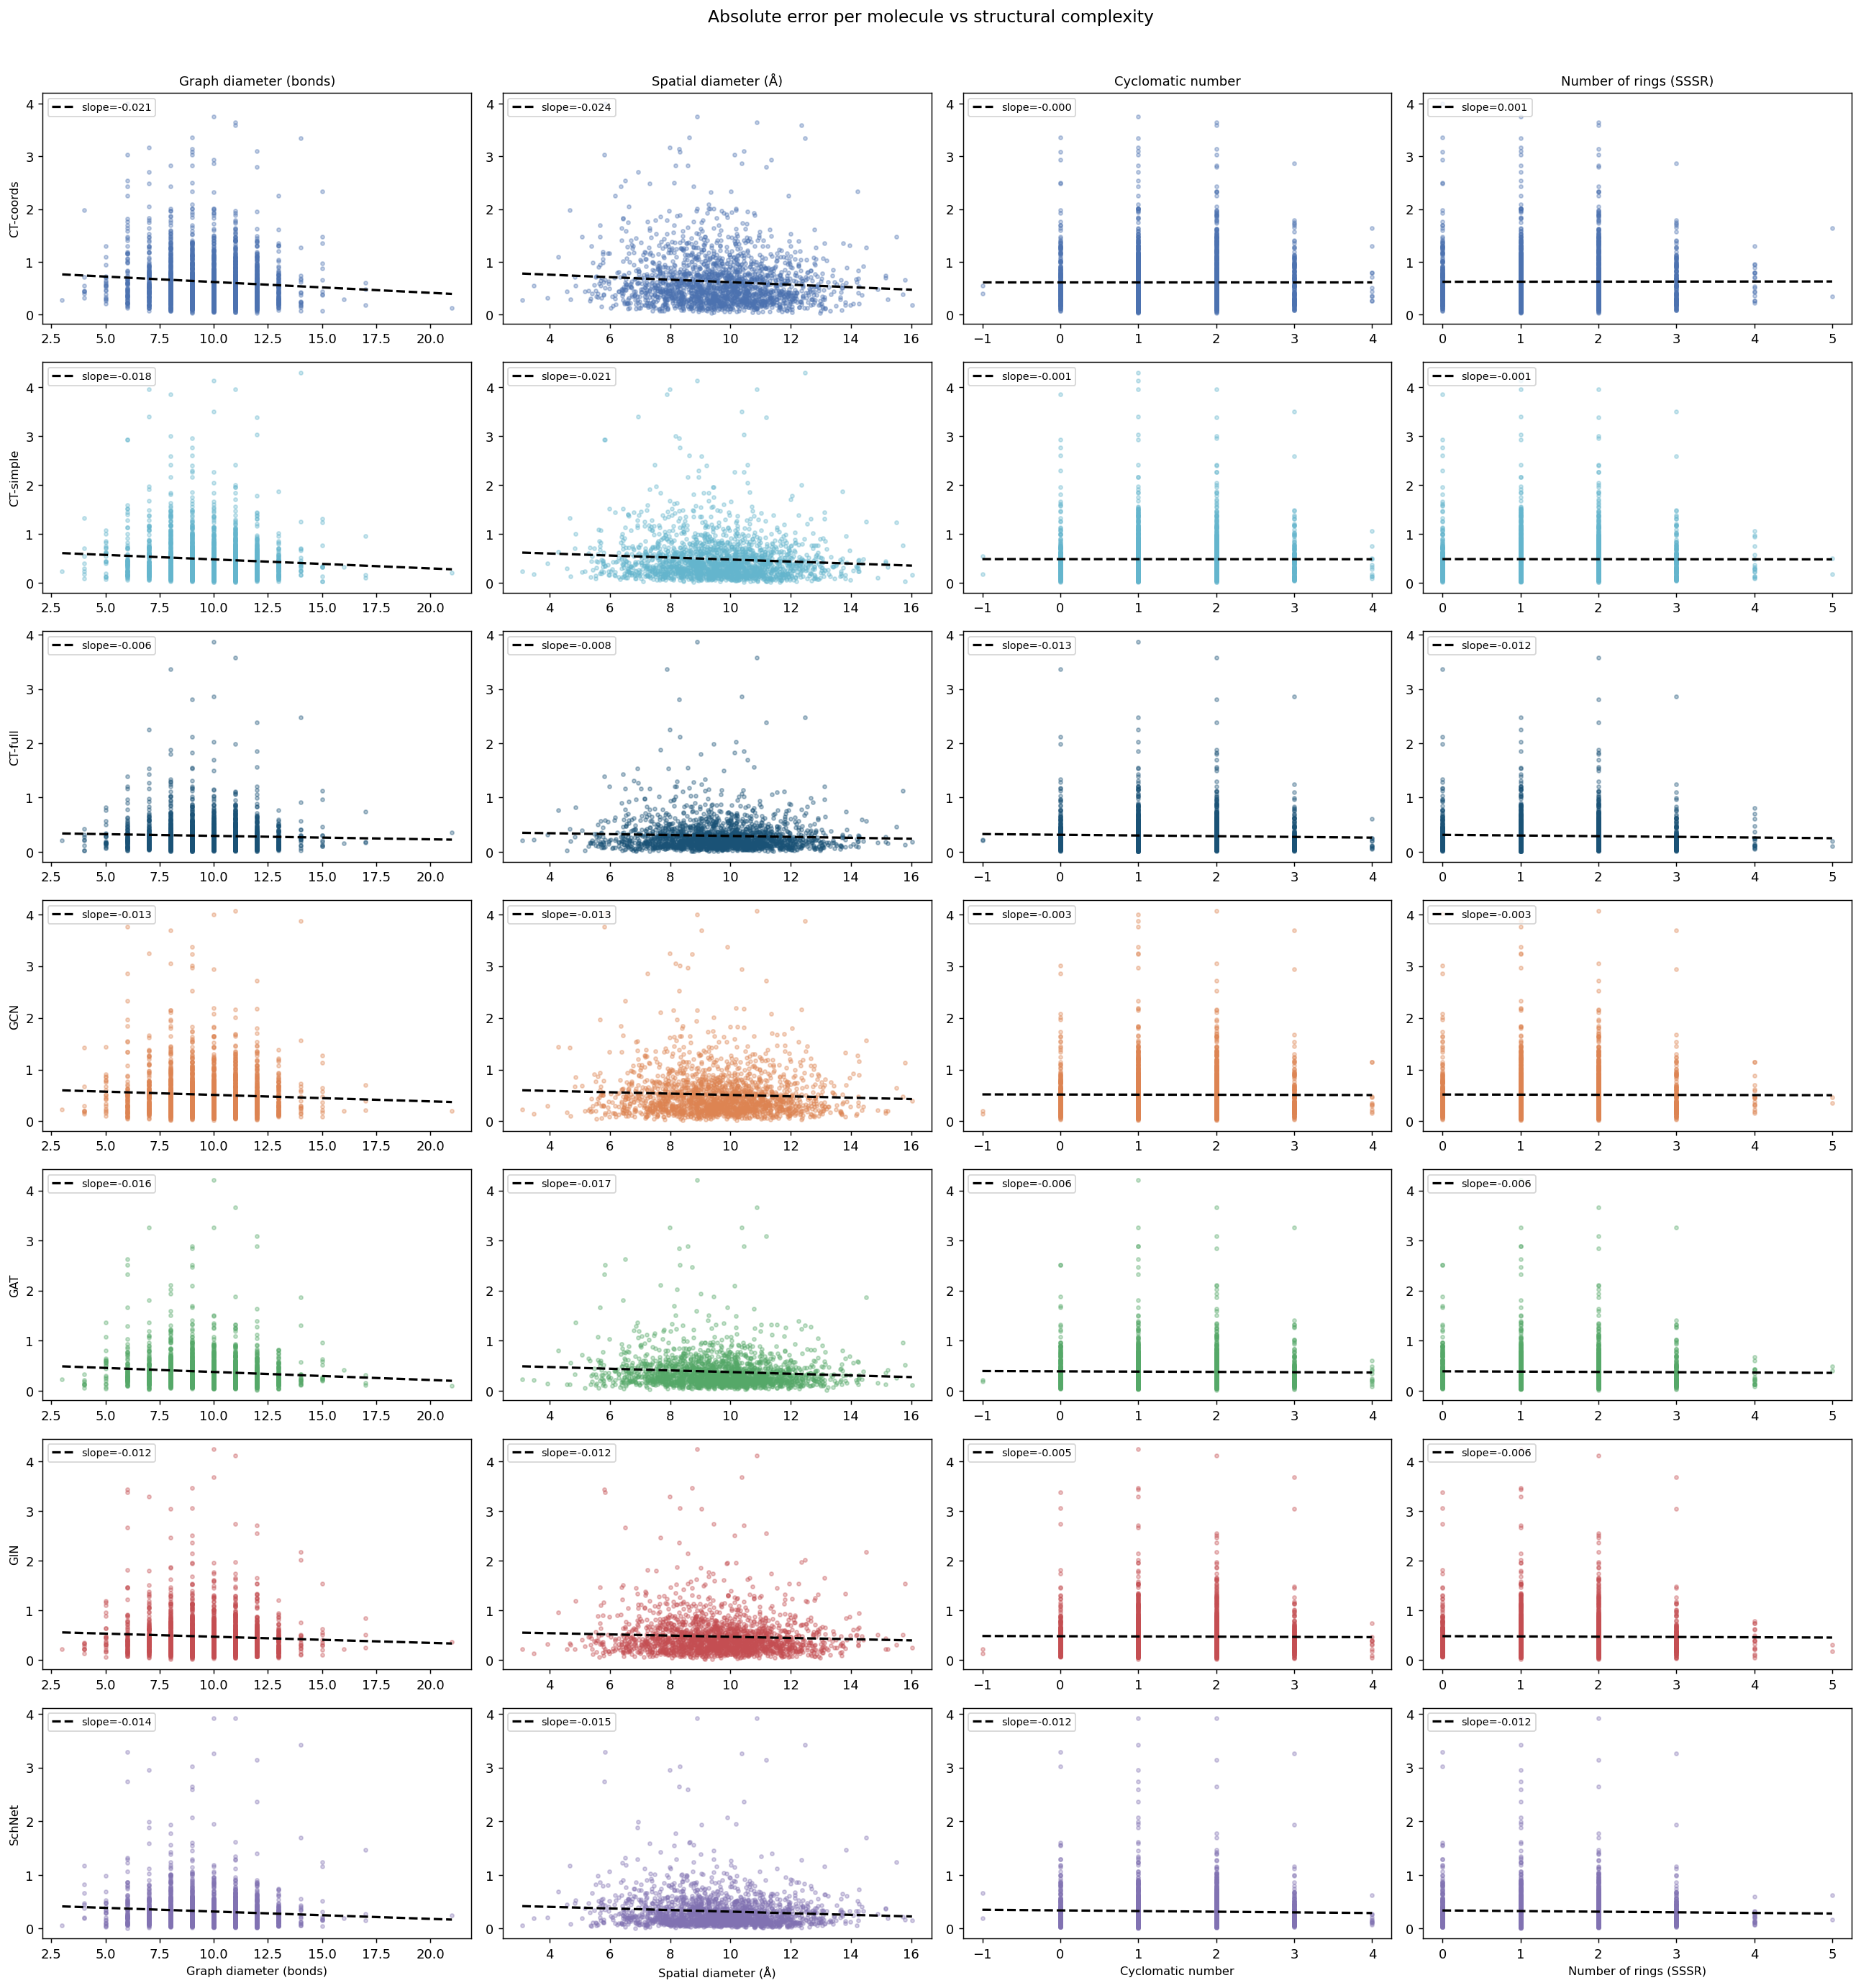

In [72]:
n_models = len(model_errors)
fig, axes = plt.subplots(n_models, 4, figsize=(20, 3 * n_models))

for row, (label, d) in enumerate(model_errors.items()):
    color = COLORS.get(label, 'gray')
    for col, (metric, xlabel) in enumerate([('gd', 'Graph diameter (bonds)'),
                                            ('sd', 'Spatial diameter (Å)'),
                                            ('cn', 'Cyclomatic number'),
                                            ('nr', 'Number of rings (SSSR)')]):
        ax = axes[row, col]
        x = d[metric]
        y = d['err']

        ax.scatter(x, y, color=color, alpha=0.35, s=8, rasterized=True)

        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, np.polyval(coeffs, x_line), color='black',
                linewidth=1.8, linestyle='--',
                label=f'slope={coeffs[0]:.3f}')
        ax.legend(fontsize=8, loc='upper left')

        if row == 0:
            ax.set_title(xlabel, fontsize=10)
        if col == 0:
            ax.set_ylabel(label, fontsize=9)
        if row == n_models - 1:
            ax.set_xlabel(xlabel, fontsize=9)

plt.suptitle('Absolute error per molecule vs structural complexity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()